In [48]:
import matplotlib.pyplot as plt
import numpy as np

In [49]:
import h5py

# Open models created during fit

In [23]:
with h5py.File('mcmc_models.h5', 'r') as f:
    # Check the available datasets
    print("Keys in the HDF5 file:", list(f.keys()))
    
    # Access a dataset (replace 'your_dataset' with the actual name)
    dataset = f['mcmc_models']
    
    # Read the data into a NumPy array
    model_cube = dataset[:]

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'mcmc_models.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [24]:
with h5py.File('mcmc_data.h5', 'r') as f:
    # Check the available datasets
    print("Keys in the HDF5 file:", list(f.keys()))
    
    # Access a dataset (replace 'your_dataset' with the actual name)
    dataset = f['mcmc_data']
    
    # Read the data into a NumPy array
    data_real = dataset[:]
mc_data = data_real[0]

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'mcmc_data.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [25]:
model_cube.shape

NameError: name 'model_cube' is not defined

In [26]:
plt.imshow(model_cube[-5,62])
plt.colorbar()

NameError: name 'model_cube' is not defined

Image above is the model for a point in the chain. It clearly shows that there is a problem

Below are the data that we are trying to fit

  0%|                                                                                                                                                                  | 0/1 [13:25<?, ?it/s]


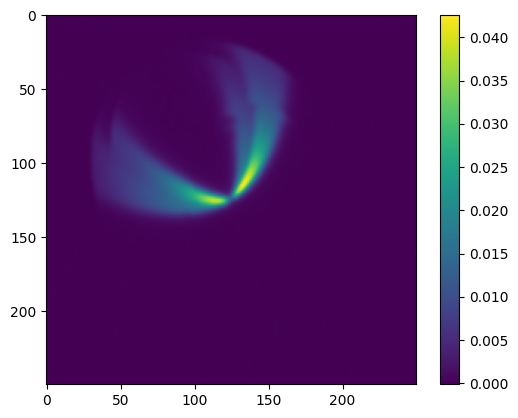

In [186]:
plt.imshow(data_real[0,62])
plt.colorbar()

# Trying to reconstruct the fitting procedure

In [27]:
# This does everything before run_mcmc
%run load_model.py

     _  _                        _                    
  __| |(_) ___   ___  _ __ ___  (_) _ __    ___  _ __ 
 / _` || |/ __| / __|| '_ ` _ \ | || '_ \  / _ \| '__|
| (_| || |\__ \| (__ | | | | | || || | | ||  __/| |   
 \__,_||_||___/ \___||_| |_| |_||_||_| |_| \___||_|   
                                                      

*====================================================================================================*
Computing grid...
Grid maximum extent: 56847190865999.51
Grid step (cell size): 456603942698.7912
*====================================================================================================*
*====================================================================================================*
Computing grid...
Grid maximum extent: 62326438178385.0
Grid step (cell size): 456603942698.7912
*====================================================================================================*
Setting beam_info var to Beam: BMAJ=0.10399999999999968 arcsec

The following reproduces what is done during a step of the mcmc fit

In [28]:
data = datacube.data
p0_mean=p0
vchannels=datacube.vchannels
nwalkers=nwalkers
nsteps=nsteps
tag=tag_out
nthreads=1
# If not specified considers maximum possible number of cores
frac_stats=0.1
frac_stddev=0.1
noise_stddev=noise

In [29]:
self = model

In [30]:
#setting data and vchannels properly
if data is None and vchannels is None:
    self.mc_data = self.datacube.data
    self.mc_vchannels = self.vchannels
elif data is not None and vchannels is not None:
    self.mc_data = data
    self.mc_vchannels = vchannels
else:
    raise InputError((data, vchannels),
                     'Please specify both data AND vchannel slices you wish to consider for the MCMC sampling.')
self.mc_nchan = len(vchannels)
self.noise_stddev = noise_stddev

In [31]:
import emcee as sampler_id

In [32]:
kwargs_model = {}
kwargs_model.update({'z_mirror': False})

In [33]:
import copy
from discminer.disc2d import Model
self.mc_header, self.mc_kind, self.mc_nparams, self.mc_boundaries_list, self.mc_params_indices = Model._get_params2fit(self.mc_params, self.mc_boundaries)
#self.params = copy.deepcopy(self.mc_params)

In [34]:
self.params = copy.deepcopy(self.mc_params)

In [35]:
if isinstance(p0_mean, (list, tuple, np.ndarray)): 
    if len(p0_mean) != self.mc_nparams: raise InputError(p0_mean, 'Length of input p0_mean must be equal to the number of parameters to fit: %d'%self.mc_nparams)
    else: pass

In [36]:
nstats = int(round(frac_stats*(nsteps-1)))
ndim = self.mc_nparams

p0_stddev = [frac_stddev*(self.mc_boundaries_list[i][1] - self.mc_boundaries_list[i][0]) for i in range(self.mc_nparams)]
p0 = np.random.normal(loc=p0_mean,
                      scale=p0_stddev,
                     size=(nwalkers, ndim)
                     )

now this is inside ln_likelihood

In [37]:
new_params = p0[0]

In [38]:
for i in range(self.mc_nparams):
    if not (self.mc_boundaries_list[i][0] < new_params[i] < self.mc_boundaries_list[i][1]): -np.inf
    else: self.params[self.mc_kind[i]][self.mc_header[i]] = new_params[i]

In [39]:
self.params

{'velocity': {'Mstar': 1.97,
  'vel_sign': 1,
  'vsys': 5.77,
  'norm': False,
  'extrap_vfunc': <function fforge.utils.utils.nullv(coord, Mstar=1.0, vel_sign=1, vsys=0)>,
  'alpha': 0,
  'h': np.float64(0.8672197884683025),
  'planetMass': np.float64(0.37041428702432444),
  'sigmaSlope': None,
  'flaringIndex': np.float64(-0.13945206037387187),
  'R_p': 39045044252700.0,
  'phi_p': 0.9948376736367678},
 'orientation': {'incl': 0.7977900010866079,
  'PA': 0.7391469382195985,
  'xc': 0.0,
  'yc': 0.0},
 'intensity': {'I0': 0.3034, 'p': -4.16, 'q': 3.68, 'Rout': 380},
 'linewidth': {'L0': 0.08, 'p': 0.86, 'q': -1.38},
 'lineslope': {'Ls': 1.85, 'p': 0.21, 'q': 0.0},
 'height_upper': {'z0': 29.78, 'p': 1.21, 'Rb': 4.36, 'q': 1.98},
 'height_lower': {'z0': 19.91, 'p': 1.09, 'Rb': 0.03, 'q': 4.18}}

In [40]:
self.intensity_func(self.coord, **self.params['intensity'])

AttributeError: 'Model' object has no attribute 'coord'

In [41]:
vel2d, int2d, linew2d, lineb2d = self.make_model(z_mirror=False, make_convolve=False)

1
2
Emulating vphi
it is this line right?
tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]])
here 1
here 2
here3
tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
    

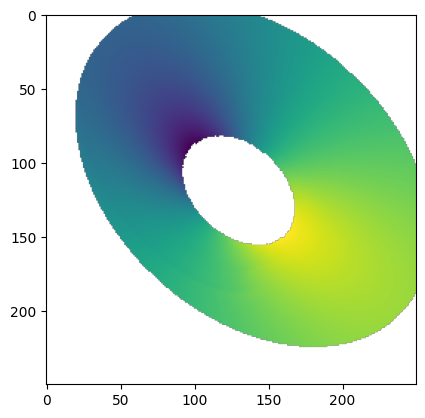

In [45]:
model_cube = self.get_cube(self.mc_vchannels, vel2d, int2d, linew2d, lineb2d, return_data_only=True)
plt.imshow(np.log10(vel2d['upper']))

In [36]:
model_cube = self.get_cube(self.mc_vchannels, np.nan_to_num(vel2d), int2d, linew2d, lineb2d, return_data_only=True)

In [37]:
model.params

{'velocity': {'Mstar': 1.97,
  'vel_sign': 1,
  'vsys': 5.77,
  'norm': False,
  'extrap_vfunc': <function fforge.utils.utils.nullv(coord, Mstar=1.0, vel_sign=1, vsys=0)>,
  'alpha': 0,
  'h': np.float64(0.6860933827263315),
  'planetMass': np.float64(0.21610999181072588),
  'sigmaSlope': None,
  'flaringIndex': np.float64(0.06301832972698415),
  'R_p': 39045044252700.0,
  'phi_p': 0.9948376736367678},
 'orientation': {'incl': 0.7977900010866079,
  'PA': 0.7391469382195985,
  'xc': 0.0,
  'yc': 0.0},
 'intensity': {'I0': 0.3034, 'p': -4.16, 'q': 3.68, 'Rout': 380},
 'linewidth': {'L0': 0.08, 'p': 0.86, 'q': -1.38},
 'lineslope': {'Ls': 1.85, 'p': 0.21, 'q': 0.0},
 'height_upper': {'z0': 29.78, 'p': 1.21, 'Rb': 4.36, 'q': 1.98},
 'height_lower': {'z0': 19.91, 'p': 1.09, 'Rb': 0.03, 'q': 4.18}}

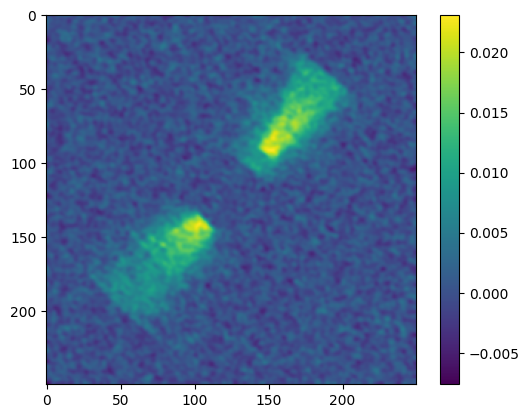

In [47]:
plt.imshow(datacube.data[10])
plt.colorbar()

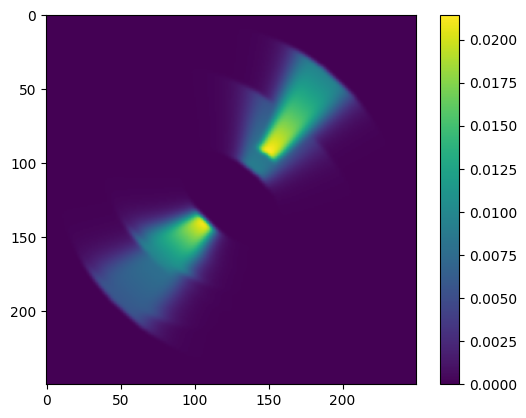

In [46]:
plt.imshow(model_cube[10])
plt.colorbar()

In [58]:
mass = np.logspace(-5,-2,200)

In [59]:
np.argmin(np.abs(mass-0.0006))

np.int64(118)

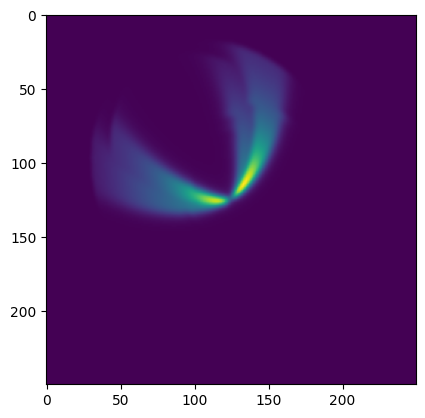

In [60]:
plt.imshow(emulated_cmaps[0,118,62])

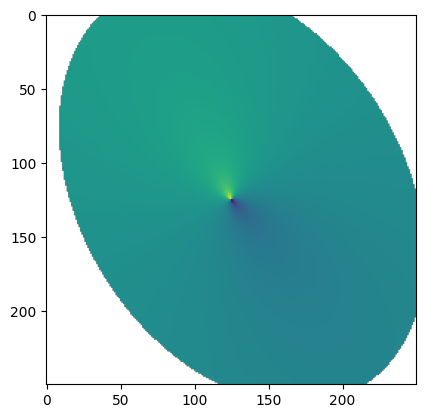

In [51]:
plt.imshow(vel2d['upper'])

In [29]:
new_params = p0
self = model
for i in range(self.mc_nparams):
            if not (self.mc_boundaries_list[i][0] < new_params[i] < self.mc_boundaries_list[i][1]): -np.inf
            else: self.params[self.mc_kind[i]][self.mc_header[i]] = new_params[i]

vel2d, int2d, linew2d, lineb2d = self.make_model()

In [31]:
model.velocity_func

<bound method Emulator.emulate_v2d of <discminer.emulator.Emulator object at 0x7f9213a3a6e0>>

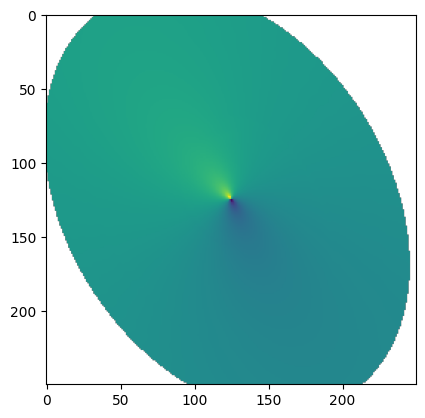

In [30]:
plt.imshow(vel2d['lower'])

In [32]:
model.params['velocity']

{'Mstar': 1.973085,
 'vsys': 5.099463,
 'vel_sign': -1.0,
 'extrap_vfunc': <function discminer.disc2d.Velocity.keplerian(coord, Mstar=1.0, vel_sign=1, vsys=0)>,
 'norm': True,
 'alpha': 0.006,
 'h': 0.085,
 'planetMass': 0.0006,
 'sigmaSlope': 1.1,
 'flaringIndex': 0.1,
 'R_p': 59839148280000.0,
 'phi_p': 0.7853981633974483}

In [39]:
res = model.velocity_func(model.grid, **model.params['velocity'])

In [45]:
res[0]

array([-1.11203166, -1.11383251, -1.1156362 , ..., -1.1156362 ,
       -1.11383251, -1.11203166], shape=(96100,))

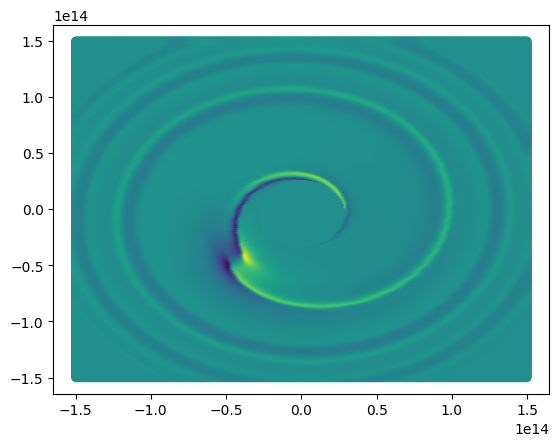

In [52]:
plt.scatter(model.grid['x'], model.grid['y'], c=res[1])

In [54]:
model.mc_vchannels = model.vchannels
model_cube = self.get_cube(self.mc_vchannels, vel2d, int2d, linew2d, lineb2d, return_data_only=True)


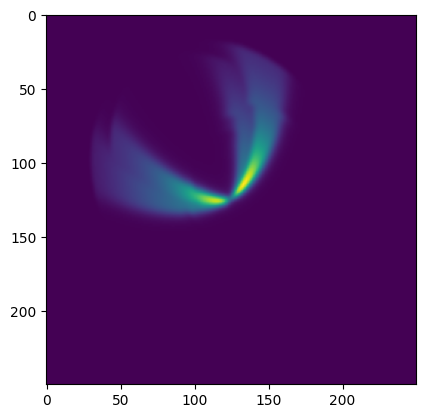

In [59]:
plt.imshow(model_cube[62])

In [58]:
model.params['velocity']

{'Mstar': 1.973085,
 'vsys': 5.099463,
 'vel_sign': -1.0,
 'extrap_vfunc': <function discminer.disc2d.Velocity.keplerian(coord, Mstar=1.0, vel_sign=1, vsys=0)>,
 'norm': True,
 'alpha': 0.006,
 'h': 0.085,
 'planetMass': 0.0006,
 'sigmaSlope': 1.1,
 'flaringIndex': 0.1,
 'R_p': 59839148280000.0,
 'phi_p': 0.7853981633974483}

In [64]:
from discminer.mining_utils import init_data_and_model
dat, model_init = init_data_and_model()

     _  _                        _                    
  __| |(_) ___   ___  _ __ ___  (_) _ __    ___  _ __ 
 / _` || |/ __| / __|| '_ ` _ \ | || '_ \  / _ \| '__|
| (_| || |\__ \| (__ | | | | | || || | | ||  __/| |   
 \__,_||_||___/ \___||_| |_| |_||_||_| |_| \___||_|   
                                                      

*====================================================================================================*
Computing grid...
Grid maximum extent: 120689578165943.16
Grid step (cell size): 969394202136.0896
*====================================================================================================*
*====================================================================================================*
Computing grid...
Grid maximum extent: 117781395559534.89
Grid step (cell size): 969394202136.0896
*====================================================================================================*
Setting beam_info var to Beam: BMAJ=0.165413767099392 arcse

In [67]:
model_init.mc_params

{'velocity': {'Mstar': True, 'vel_sign': 1, 'vsys': 0},
 'orientation': {'incl': True, 'PA': True, 'xc': False, 'yc': False},
 'intensity': {'I0': True, 'p': True, 'q': False},
 'linewidth': {'L0': True, 'p': True, 'q': 0.1},
 'lineslope': {'Ls': False, 'p': False, 'q': False},
 'height_upper': {'psi': True},
 'height_lower': {'psi': True}}

In [68]:
model.mc_params

{'velocity': {'Mstar': 1.973085,
  'vel_sign': -1,
  'vsys': 0,
  'extrap_vfunc': <function discminer.disc2d.Velocity.keplerian(coord, Mstar=1.0, vel_sign=1, vsys=0)>,
  'alpha': True,
  'h': True,
  'planetMass': True,
  'sigmaSlope': True,
  'flaringIndex': True,
  'R_p': True,
  'phi_p': True},
 'orientation': {'incl': 0.7853981633974483,
  'PA': 1.010296,
  'xc': False,
  'yc': False},
 'intensity': {'I0': 0.10439999999999999, 'p': -2.659016, 'q': 2.156254},
 'linewidth': {'L0': 0.316459, 'p': -0.288951, 'q': -0.355926},
 'lineslope': {'Ls': False, 'p': False, 'q': False},
 'height_upper': {'z0': 52.680114,
  'p': 1.65208,
  'Rb': 108.607483,
  'q': 0.550336},
 'height_lower': {'z0': 14.227028,
  'p': 1.107099,
  'Rb': 803.90594,
  'q': 2.859784}}

# check minimu

In [121]:
from astropy.io import fits
data = fits.open('fake_data_id4_rms1e-5.fits')[0].data

In [126]:
from tqdm import tqdm

In [21]:
def ln_likelihood(model_cube, mc_data, noise=1):
    lnx2 = 0
    for i in range(model_cube.shape[0]):
        model_chan = model_cube[i]
        mask_data = np.isfinite(mc_data[i])
        mask_model = np.isfinite(model_chan)
        data = np.where(np.logical_and(mask_model, ~mask_data), 0, mc_data[i])
        model = np.where(np.logical_and(mask_data, ~mask_model), 0, model_chan)
        mask = np.logical_and(mask_data, mask_model)
        lnx =  np.where(mask, np.power((data - model)/noise, 2), 0) 
        lnx2 += -0.5 * np.sum(lnx)
    
    return lnx2 if np.isfinite(lnx2) else -np.inf

In [189]:
emulated_cmaps = np.load('../generate_cmaps/modelcubes_emu_conv_varyingonlyplanetmass_id4_jb.npy')

In [193]:
lk = [ln_likelihood(m, data) for m in tqdm(emulated_cmaps[0])]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:08<00:00, 24.18it/s]


In [194]:
self.noise_stddev

1e-05

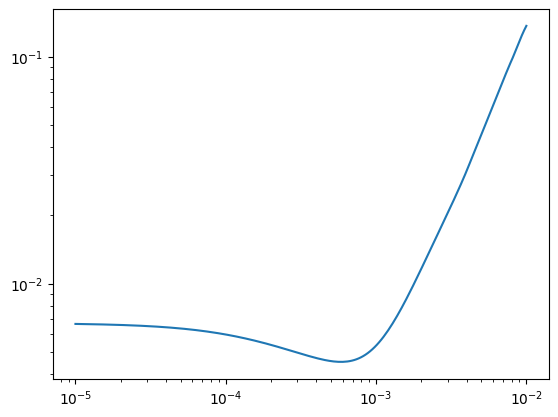

In [195]:
nlk = -1*np.array(lk)
plt.plot(np.logspace(-5,-2,200), nlk)
plt.yscale('log')
plt.xscale('log')

In [145]:
data.shape

(133, 250, 250)

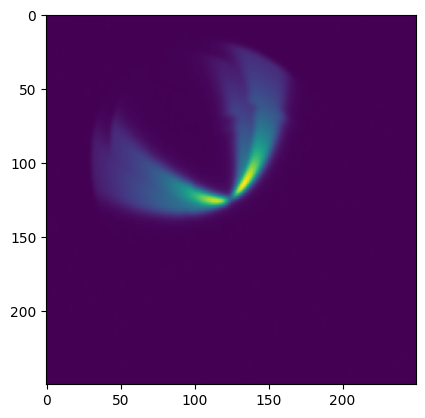

In [146]:
plt.imshow(data[62])

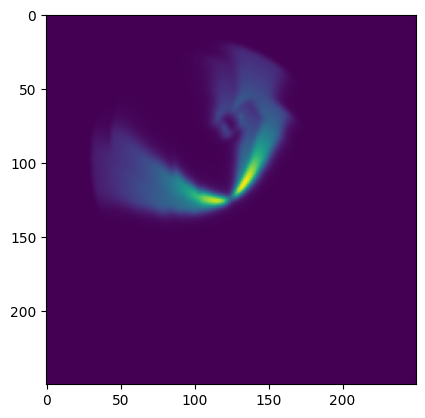

In [152]:
plt.imshow(emulated_cmaps[0][199][62])